In [7]:
df = pd.read_csv('processed_player_data.csv')
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("NaN counts:\n", df.isna().sum())

Rows: 10306
Columns: ['matchid', 'inning', 'batsman', 'runs_scored', 'balls_faced', 'batting_team', 'bowling_team', 'venue', 'season', 'date', 'team1', 'team2', 'strike_rate', 'innings_played', 'batsman_avg', 'balls_faced_avg', 'historical_sr', 'avg_vs_opp', 'opp_strength', 'home_advantage', 'season_year', 'venue_encoded']
NaN counts:
 matchid                0
inning                 0
batsman                0
runs_scored            0
balls_faced            0
batting_team           0
bowling_team           0
venue                  0
season                 0
date               10306
team1                  0
team2                  0
strike_rate            0
innings_played         0
batsman_avg            0
balls_faced_avg        0
historical_sr          0
avg_vs_opp             0
opp_strength           0
home_advantage         0
season_year            0
venue_encoded          0
dtype: int64


Valid rows: 10306
Target mean / std: 20.8 / 21.48
Random 85/15 split
Train: 8760   Test: 1546

Baseline    MSE: 441.93  MAE: 16.58  R²: -0.0001
RandomForest MSE: 393.89  MAE: 15.06  R²: 0.1086   CV R²: 0.0678
XGBoost     MSE: 426.81  MAE: 15.56  R²: 0.0341   CV R²: -0.0385


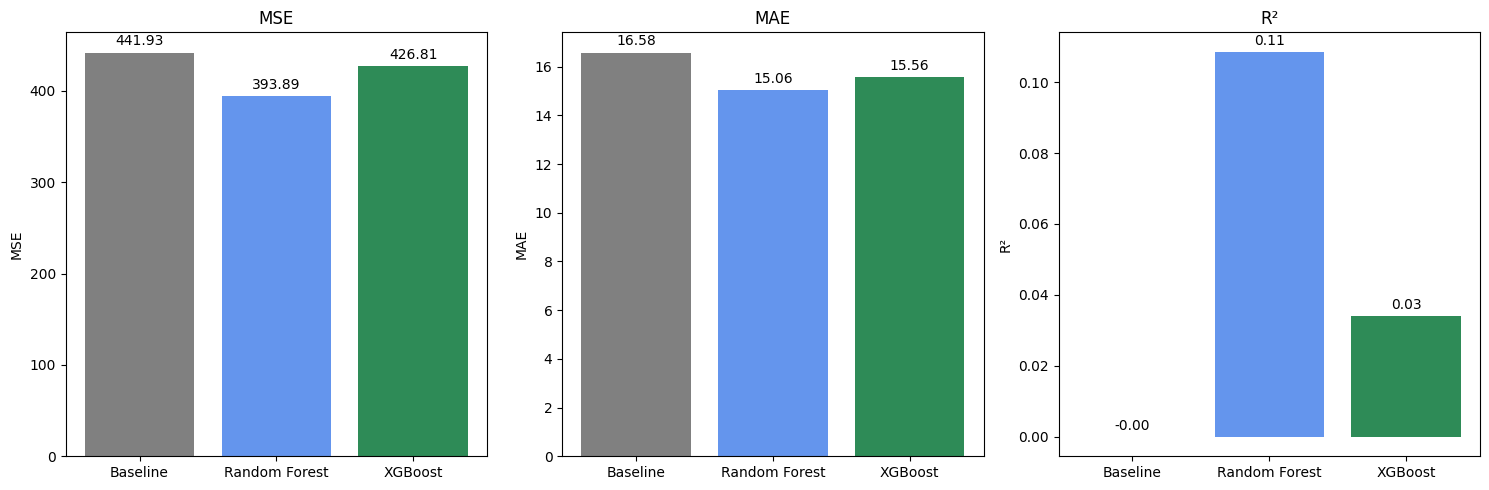

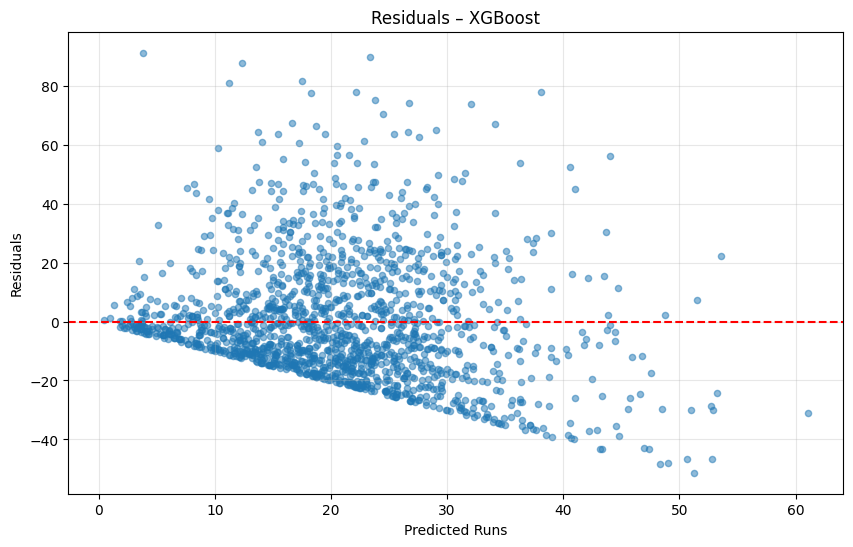


XGBoost Feature Importance:
balls_faced_avg    0.2227
batsman_avg        0.2207
opp_strength       0.1957
avg_vs_opp         0.1843
historical_sr      0.1766
venue_encoded      0.0000
home_advantage     0.0000
season_year        0.0000
dtype: float32


In [8]:
import pandas as pd
import numpy as np
import joblib
from sklearn.model_selection import train_test_split, cross_val_score, TimeSeriesSplit
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('processed_player_data.csv')

feature_cols = [
    'batsman_avg',
    'historical_sr',
    'balls_faced_avg',
    'avg_vs_opp',
    'venue_encoded',
    'opp_strength',
    'home_advantage',
    'season_year'
]

target = 'runs_scored'

df_model = df[feature_cols + [target]].dropna()

X = df_model[feature_cols]
y = df_model[target]

print("Valid rows:", len(X))
print("Target mean / std:", round(y.mean(), 2), "/", round(y.std(), 2))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=42
)
print("Random 85/15 split")
print(f"Train: {len(X_train)}   Test: {len(X_test)}")

baseline_pred = np.full(len(y_test), y_train.mean())
baseline_mse = mean_squared_error(y_test, baseline_pred)
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2  = r2_score(y_test, baseline_pred)

rf = RandomForestRegressor(
    n_estimators=400,
    max_depth=14,
    min_samples_split=4,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_mse = mean_squared_error(y_test, rf_pred)
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_r2  = r2_score(y_test, rf_pred)

tscv = TimeSeriesSplit(n_splits=5)
rf_cv_r2 = cross_val_score(rf, X_train, y_train, cv=tscv, scoring='r2')

xgb = XGBRegressor(
    n_estimators=600,
    max_depth=7,
    learning_rate=0.035,
    subsample=0.85,
    colsample_bytree=0.75,
    reg_lambda=1.2,
    reg_alpha=0.1,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

xgb_mse = mean_squared_error(y_test, xgb_pred)
xgb_mae = mean_absolute_error(y_test, xgb_pred)
xgb_r2  = r2_score(y_test, xgb_pred)

xgb_cv_r2 = cross_val_score(xgb, X_train, y_train, cv=tscv, scoring='r2')

joblib.dump(rf, 'rf_model.pkl')
joblib.dump(xgb, 'xgb_model.pkl')

print("\nBaseline    MSE:", round(baseline_mse,2), " MAE:", round(baseline_mae,2), " R²:", round(baseline_r2,4))
print("RandomForest MSE:", round(rf_mse,2), " MAE:", round(rf_mae,2), " R²:", round(rf_r2,4), "  CV R²:", round(rf_cv_r2.mean(),4))
print("XGBoost     MSE:", round(xgb_mse,2), " MAE:", round(xgb_mae,2), " R²:", round(xgb_r2,4), "  CV R²:", round(xgb_cv_r2.mean(),4))

models = ['Baseline', 'Random Forest', 'XGBoost']
mse_vals = [baseline_mse, rf_mse, xgb_mse]
mae_vals = [baseline_mae, rf_mae, xgb_mae]
r2_vals  = [baseline_r2, rf_r2, xgb_r2]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = ['MSE', 'MAE', 'R²']

for ax, vals, title in zip(axes, [mse_vals, mae_vals, r2_vals], titles):
    ax.bar(models, vals, color=['gray','cornflowerblue','seagreen'])
    ax.set_title(title)
    ax.set_ylabel(title)
    for i, v in enumerate(vals):
        ax.text(i, v + 0.01*max(vals), f'{v:.2f}', ha='center', va='bottom')

plt.tight_layout()
plt.savefig('model_comparison.png')
plt.show()

residuals = y_test - xgb_pred
plt.figure(figsize=(10,6))
plt.scatter(xgb_pred, residuals, alpha=0.5, s=20)
plt.axhline(0, color='red', linestyle='--', lw=1.5)
plt.xlabel('Predicted Runs')
plt.ylabel('Residuals')
plt.title('Residuals – XGBoost')
plt.grid(alpha=0.3)
plt.savefig('residuals_xgb.png')
plt.show()

importances = pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nXGBoost Feature Importance:")
print(importances.round(4))